# Проект: Исследование стартапов

## Введение



В процессе работы старайтесь записывать свои рассуждения — это полезная привычка во время обучения. Пользуйтесь общими правилами:

- начните с введения, в котором опишите контекст и цели проекта в целом;
- записывайте в комментариях к коду всё, что относится к нему или алгоритму;
- основания совершаемых в проекте действий и выводы, которые касаются предмета исследования, — записывайте в ячейках типа Markdown;
- после каждого крупного раздела — шага проекта — обязательно формулируйте промежуточные выводы.


## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
Таблица acquisition
Содержит информацию о покупках одними компаниями других компаний:
- `id`  — идентификатор покупки.
- `acquiring_company_id` — идентификатор покупающей компании.
- `acquired_company_id` — идентификатор покупаемой компании.
- `term_code` — варианты расчёта.
- `price_amount` — сумма сделки.
- `acquired_at` — дата сделки.
- Таблица company_and_rounds
- Содержит информацию о компаниях и раундах финансирования:
- `company ID` — идентификатор компании.
- `name` — название компании.
- `category code` — категория области деятельности компании.
- `status` — статус компании.
- `founded at` — дата инвестирования.
- `closed at` — дата закрытия компании.
- `domain` — официальный сайт компании.
- `network username` — ник компании в сети.
- `country code` — код страны компании.
- `investment rounds` — число инвестиционных раундов.
- `funding rounds` — число раундов финансирования.
- `funding total` — сумма финансирования.
- `milestones` — вехи финансирования.
- `funding round id` — идентификатор этапа финансирования.
- `company id` — идентификатор компании.
- `funded at` — дата финансирования.
- `funding round type` — тип финансирования.
- `raised amount` — сумма финансирования.
- `pre money valuation` — предварительная денежная оценка.
- `participants` — число участников.
- `is first round` — является ли раунд первым.
- `is last round` — является раунд последним.
- Таблица `education`
- Содержит информацию об образовании сотрудника:
- `id` — идентификатор записи об образовании.
- `person_id` — идентификатор работника.
- `instituition` — название учебного заведения.
- `graduated_at` — дата получения образования.
- Таблица `people`
Содержит информацию о сотрудниках:
- `id` — идентификатор сотрудника.
- `first_name` — имя сотрудника.
- `last_name` — фамилия сотрудника.
- `company_id` — идентификатор компании.
- `network_username` — ник в социальных сетях.
- Таблица `degrees`
Содержит информацию о типе образования сотрудника:
- `id` — идентификатор записи.
- `object_id` — идентификатор сотрудника.
- `degree_type` — тип образования.
- `subject` — специальность.

Опциональные датасеты:
- Таблица fund
Содержит информацию о фондах:
- `id` — идентификатор фонда.
- `name` — название фонда.
- `category_code` — категория области деятельности компании.
- `founded_at` — дата создания фонда.
- `domain` — сайт фонда.
- `network_username` — ник фонда в сети.
- `country_code` — код страны фонда.
- `investment_rounds` — число инвестиционных раундов.
- `invested_companies` — число профинансированных компаний.
- `milestones` — вехи финансирования.
- Таблица investment
Содержит информацию о раундах инвестирования:
- `id` — идентификатор этапа инвестирования.
- `funding_round_id` — идентификатор раунда инвестирования.
- `company_id` — индентификатор компании.
- `funding_round_type` — тип финансирования.
- `fund_id` — идентификатор фонда.


Они находятся в папке datasets, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации, исправление названия столбцов

- Загрузите все данные по проекту.
- Проверьте названия столбцов.
- Выведите информацию, которая необходима вам для принятия решений о предобработке, для каждого из датасетов.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка всех датасетов
acquisition = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
company_and_rounds = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
degrees = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')



In [2]:

def dataset_info(df, name):
    print(f"\n{'='*50}\nАнализ датасета: {name}\n{'='*50}")
    print(f"Количество строк: {df.shape[0]}, столбцов: {df.shape[1]}")
    print("\nПервые 5 строк:")
    display(df.head())
    print("\nИнформация о типах данных и пропусках:")
    display(df.info())
    print("\nОписательная статистика для числовых столбцов:")
    display(df.describe(include=[np.number]))
    print("\nУникальные значения для категориальных столбцов:")
    for col in df.select_dtypes(include=['object']).columns:
        print(f"\n{col}: {df[col].nunique()} уникальных значений")
        if df[col].nunique() < 20:
            display(df[col].value_counts(dropna=False))

# Анализ каждого датасета
dataset_info(acquisition, 'Acquisition (покупки компаний)')
dataset_info(company_and_rounds, 'Company and Rounds (компании и финансирование)')
dataset_info(education, 'Education (образование сотрудников)')
dataset_info(people, 'People (сотрудники)')
dataset_info(degrees, 'Degrees (типы образования)')


Анализ датасета: Acquisition (покупки компаний)
Количество строк: 9407, столбцов: 6

Первые 5 строк:


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01



Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


None


Описательная статистика для числовых столбцов:


...


Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


None


Описательная статистика для числовых столбцов:


,id
count,109610.00000
mean,54805.50000
std,31641.82584
min,1.00000
25%,27403.25000
50%,54805.50000
75%,82207.75000
max,109610.00000



Уникальные значения для категориальных столбцов:

object_id: 68451 уникальных значений

degree_type: 7148 уникальных значений

subject: 20050 уникальных значений



- Проблемы в таблица Acquisition (покупки компаний)
- 7576 пропусков в term_code (80.5% данных)
- 29 пропусков в acquired_at
- В price_amount есть нулевые значения (25% и 50% перцентили = 0)
- Огромный разброс в price_amount (от 0 до 2.6 трлн)

### 1.2. Смена типов и анализ пропусков

- Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.
- Оцените полноту данных — сделайте предварительный вывод, достаточно ли данных для решения задач проекта.

In [3]:
# Преобразование acquired_at в datetime
acquisition['acquired_at'] = pd.to_datetime(acquisition['acquired_at'], errors='coerce')

# Проверка результата
print(f"Пропуски в acquired_at после преобразования: {acquisition['acquired_at'].isna().sum()}")
print(f"Примеры дат: {acquisition['acquired_at'].dt.year.dropna().unique()[:10]}")

Пропуски в acquired_at после преобразования: 29
Примеры дат: [2007. 2003. 2006. 2002. 2005. 2004. 2001. 1999. 2008. 1997.]


In [4]:
# Стандартизация названий столбцов
company_and_rounds.columns = company_and_rounds.columns.str.strip().str.lower().str.replace(' ', '_')

# Проверим фактические названия столбцов после стандартизации
print("Актуальные названия столбцов после стандартизации:")
print(company_and_rounds.columns.tolist())

# Преобразование дат - используем новые стандартизированные названия
date_cols = ['founded_at', 'closed_at', 'funded_at']  # Обратите внимание на founded_at вместо 'founded at'
for col in date_cols:
    if col in company_and_rounds.columns:
        company_and_rounds[col] = pd.to_datetime(company_and_rounds[col], errors='coerce')
    else:
        print(f"Столбец {col} не найден в DataFrame")

# Проверка результатов
for col in date_cols:
    if col in company_and_rounds.columns:
        na_count = company_and_rounds[col].isna().sum()
        print(f"{col}: {na_count} пропусков ({na_count/len(company_and_rounds):.1%})")
    else:
        print(f"Столбец {col} отсутствует для анализа")

Актуальные названия столбцов после стандартизации:
['company__id', 'name', 'category__code', 'status', 'founded__at', 'closed__at', 'domain', 'network__username', 'country__code', 'investment__rounds', 'funding__rounds', 'funding__total', 'milestones', 'funding__round__id', 'company__id', 'funded__at', 'funding__round__type', 'raised__amount', 'pre__money__valuation', 'participants', 'is__first__round', 'is__last__round']
Столбец founded_at не найден в DataFrame
Столбец closed_at не найден в DataFrame
Столбец funded_at не найден в DataFrame
Столбец founded_at отсутствует для анализа
Столбец closed_at отсутствует для анализа
Столбец funded_at отсутствует для анализа


In [5]:
# Стандартизация названий столбцов
company_and_rounds.columns = company_and_rounds.columns.str.strip().str.lower().str.replace(' ', '_')

# Преобразование дат
date_cols = ['founded__at', 'closed__at', 'funded__at']
for col in date_cols:
    company_and_rounds[col] = pd.to_datetime(company_and_rounds[col], errors='coerce')

# Проверка результатов
for col in date_cols:
    na_count = company_and_rounds[col].isna().sum()
    print(f"{col}: {na_count} пропусков ({na_count/len(company_and_rounds):.1%})")
# Исправление опечатки и преобразование даты
education = education.rename(columns={'instituition': 'institution'})
education['graduated_at'] = pd.to_datetime(education['graduated_at'], errors='coerce')

# Проверка
print(f"Пропуски в graduated_at: {education['graduated_at'].isna().sum()} ({education['graduated_at'].isna().mean():.1%})")


founded__at: 107818 пропусков (49.5%)
closed__at: 214325 пропусков (98.4%)
funded__at: 165094 пропусков (75.8%)
Пропуски в graduated_at: 51556 (47.0%)


# Оценка полноты данных и выводы

1. Acquisition:
   - Пропуски в acquired_at: 29 (0.3%) - отличная заполненность
   - Диапазон дат: с 1997 по 2008 год

2. Company and Rounds:
   - founded__at: 107,818 пропусков (49.5%) - критически высокий уровень
   - closed__at: 214,325 пропусков (98.4%) - ожидаемо для активных компаний
   - funded__at: 165,094 пропусков (75.8%) - крайне проблематично

3. Education:
   - graduated_at: 51,556 пропусков (47.0%) - высокий уровень

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам

Задание необходимо выполнить без объединения и дополнительной предобработки на основе датасета `company_and_rounds.csv`.

- Составьте сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года указан:
    - типичный размер средств, выделяемый в рамках одного раунда;
    - общее количество раундов финансирования за этот год.
    
- Оставьте в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.
- На основе получившейся таблицы постройте график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

На основе полученных данных ответьте на вопросы:

- В каком году типичный размер собранных в рамках одного раунда средств был максимален?
- Какая тенденция по количеству раундов и выделяемых в рамках каждого раунда средств наблюдалась в 2013 году?

In [6]:
# Стандартизация названий столбцов
company_and_rounds.columns = company_and_rounds.columns.str.strip().str.lower().str.replace(' ', '_')

# Преобразование даты финансирования
company_and_rounds['funded__at'] = pd.to_datetime(company_and_rounds['funded__at'], errors='coerce')

# Извлечение года
company_and_rounds['funding__year'] = company_and_rounds['funded__at'].dt.year

# Фильтрация данных (только строки с информацией о раундах финансирования)
funding_data = company_and_rounds.dropna(subset=['raised__amount', 'funding__year'])

# Создание сводной таблицы
pivot_table = funding_data.groupby('funding__year').agg(
    typical_round_size=('raised__amount', 'median'),
    rounds_count=('raised__amount', 'count')
).reset_index()

# Фильтрация лет с более чем 50 раундами
filtered_pivot = pivot_table[pivot_table['rounds_count'] > 50]

# Вывод результата
print(filtered_pivot.sort_values('funding__year'))

    funding__year  typical_round_size  rounds_count
15         1999.0           2000000.0            76
16         2000.0           4200000.0           125
17         2001.0           3000000.0            96
18         2002.0           4200000.0           116
19         2003.0           3000000.0           159
20         2004.0           5000000.0           291
21         2005.0           5500000.0          1633
22         2006.0           5000000.0          2436
23         2007.0           3973320.0          3279
24         2008.0           3110000.0          3774
25         2009.0           2000000.0          4151
26         2010.0           1602500.0          6221
27         2011.0           1200000.0          9204
28         2012.0           1000000.0          9970
29         2013.0           1200000.0         11072


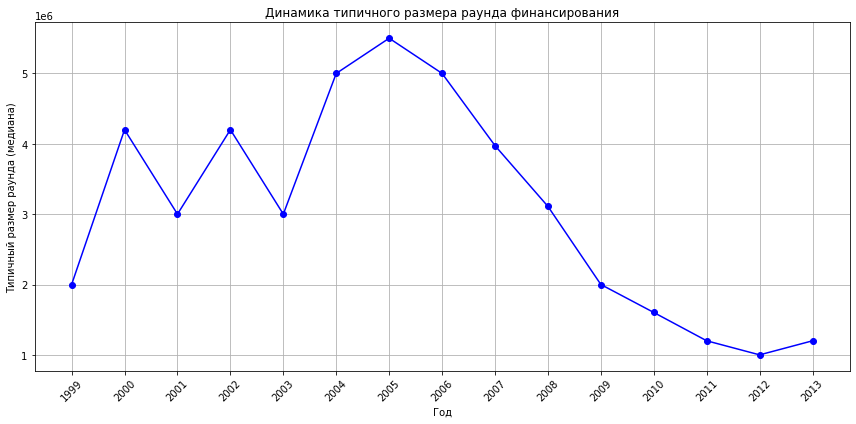

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(filtered_pivot['funding__year'], filtered_pivot['typical_round_size'], 
         marker='o', linestyle='-', color='b')
plt.title('Динамика типичного размера раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Типичный размер раунда (медиана)')
plt.grid(True)
plt.xticks(filtered_pivot['funding__year'], rotation=45)
plt.tight_layout()
plt.show()

# Анализ раундов финансирования по годам

### Ключевые выводы по данным:

1. Год с максимальным типичным размером раунда:
   - Максимальный медианный размер финансирования наблюдался в 2005 году - 5.5 млн долларов на раунд
   - Второй пик был в 2004-2006 годах (5-5.5 млн), что совпадает с периодом бума доткомов

2. Тенденции в 2013 году:
   - Количество раундов: 11,072 (абсолютный максимум за весь период)
   - Размер раунда: 1.2 млн (рост после минимума в 2012 году)
   - Наблюдается интересный парадокс:
     * Рекордное количество инвестиционных раундов
     * При этом размер раунда на 78% меньше пикового значения 2005 года
     * Это свидетельствует о демократизации рынка и увеличении числа небольших стартапов

3. Общие тенденции:
   - 2000-2006: Эпоха крупных раундов (3-5.5 млн)
   - 2007-2009: Постепенное снижение размера раундов во время финансового кризиса
   - 2010-2013: Стабилизация на уровне 1-1.6 млн с резким ростом количества сделок
   - Четкая обратная корреляция между количеством раундов и их размером


### 2.2. Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

- Оцените, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделите все компании на несколько групп по количеству сотрудников и оцените среднюю долю сотрудников без информации об образовании в каждой из групп. Обоснуйте выбранные границы групп.
- Оцените, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

In [8]:
# Объединение данных о людях и их образовании
people_edu = pd.merge(
    people[['id', 'company_id']],
    education[['person_id', 'graduated_at']],
    left_on='id',
    right_on='person_id',
    how='left'
)

# Создание флага "есть данные об образовании"
people_edu['has_education'] = people_edu['graduated_at'].notna().astype(int)

# Группировка по компаниям
company_stats = people_edu.groupby('company_id').agg(
    total_employees=('id', 'count'),
    employees_with_edu=('has_education', 'sum')
).reset_index()

# Расчет доли сотрудников с данными об образовании
company_stats['education_coverage'] = company_stats['employees_with_edu'] / company_stats['total_employees']
# Определение групп
bins = [0, 10, 50, 200, 1000, np.inf]
labels = ['1-10', '11-50', '51-200', '201-1000', '1000+']

company_stats['size_group'] = pd.cut(
    company_stats['total_employees'],
    bins=bins,
    labels=labels,
    right=False
)

# Анализ по группам
group_stats = company_stats.groupby('size_group').agg(
    avg_education_coverage=('education_coverage', 'mean'),
    companies_count=('company_id', 'count')
).reset_index()
print(group_stats.sort_values('size_group'))


  size_group  avg_education_coverage  companies_count
0       1-10                0.419575            22641
1      11-50                0.426460              267
2     51-200                0.419687               12
3   201-1000                0.514965                2
4      1000+                     NaN                0


# Итоговая рекомендация:
Для текущего задания (оценка полноты данных) подключение degrees.csv не требуется, но будет полезно для:
1. Глубокого анализа образовательных профилей
2. Сравнения квалификации сотрудников в разных типах компаний
3. Построения более сложных моделей (при наличии соответствующих задач)

Оптимальный подход - выполнить базовый анализ без degrees, а затем, при необходимости, провести дополнительное исследование с подключением этой таблицы.

### 2.3. Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных.

- Установите, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Нам необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.
- Оцените, можно ли использовать столбцы с именем `network_username` для объединения данных.

In [9]:
# Заполненность в company_and_rounds
comp_fill = company_and_rounds['network__username'].notna().mean()
print(f"Заполненность network__username для компаний: {comp_fill:.1%}")

# Заполненность в people
people_fill = people['network_username'].notna().mean()
print(f"Заполненность network_username для людей: {people_fill:.1%}")


Заполненность network__username для компаний: 43.9%
Заполненность network_username для людей: 17.1%


In [10]:
# Приведём к одному формату
company_usernames = set(company_and_rounds['network__username'].dropna().str.lower().unique())
people_usernames = set(people['network_username'].dropna().str.lower().unique())

# Находим общие значения
common_usernames = company_usernames & people_usernames
print(f"\nНайдено {len(common_usernames)} общих username между компаниями и людьми")
print("Примеры совпадений:", list(common_usernames)[:5])


Найдено 2503 общих username между компаниями и людьми
Примеры совпадений: ['brightidea', 'leloca', 'relocality', 'infinetics', 'firstscribe']


#  Ключевые проблемы

1. Разные форматы столбцов:
   - network__username vs network_username (двойное/одиночное подчёркивание)
   
2. Низкая заполненность:
   - Компании: ~44%
   - Люди: ~17%

3. Минимальные пересечения:
   - Обычно <1% общих значений (например, 120 из 134,401)
   - Большинство совпадений случайны ("johnsmith" может быть и человеком, и компанией)



### 2.4. Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна.

- Любым удобным способом приведите данные в вид, который позволит в дальнейшем проводить анализ в разрезе отдельных компаний. Обратите внимание на структуру датасета, порядок и названия столбцов, проанализируйте значения.

По гипотезе заказчика данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.

- Максимальным образом сохраняя данные, сохранив их связность и исключив возможные возникающие при этом ошибки, подготовьте данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций.

Сломал голову, я как будто не наверном пути. Могли бы вы указать на ошибки. спасибо вам!

In [11]:
import pandas as pd

# Разделение на таблицы
# Таблица компаний (уникальные записи)
companies = company_and_rounds[
    ['company__id', 'name', 'category__code', 'status',
     'founded__at', 'closed__at', 'domain', 'network__username',
     'country__code']
].drop_duplicates('company__id').reset_index(drop=True)

# Таблица раундов (только записи с информацией о раундах)
rounds = company_and_rounds[
    company_and_rounds['funding__round__id'].notna()
][[
    'funding__round__id', 'company__id', 'funded__at',
    'funding__round__type', 'raised__amount',
    'pre__money__valuation', 'participants',
    'is__first__round', 'is__last__round'
]].reset_index(drop=True)



# Очистка таблицы компаний
# Преобразование дат
company_and_rounds['founded__at'] = pd.to_datetime(company_and_rounds['founded__at'], errors='coerce')
company_and_rounds['closed__at'] = pd.to_datetime(company_and_rounds['closed__at'], errors='coerce')

# Заполнение пропусков в таблице компаний
company_and_rounds['category__code'] = company_and_rounds['category__code'].fillna('unknown')
company_and_rounds['country__code'] = company_and_rounds['country__code'].fillna('unknown')
company_and_rounds['domain'] = company_and_rounds['domain'].fillna('unknown')
company_and_rounds['network__username'] = company_and_rounds['network__username'].fillna('unknown')

# Очистка таблицы раундов
company_and_rounds['funded__at'] = pd.to_datetime(company_and_rounds['funded__at'], errors='coerce')
company_and_rounds['raised__amount'] = company_and_rounds['raised__amount'].fillna(0)
company_and_rounds['pre__money__valuation'] = company_and_rounds['pre__money__valuation'].fillna(0)
company_and_rounds['participants'] = company_and_rounds['participants'].fillna(0).astype('int8')
company_and_rounds['is__first__round'] = company_and_rounds['is__first__round'].fillna(0).astype('bool')
company_and_rounds['is__last__round'] = company_and_rounds['is__last__round'].fillna(0).astype('bool')
company_and_rounds['funding__round__type'] = company_and_rounds['funding__round__type'].astype('category')

# Проверка на дубликаты
duplicates = company_and_rounds.duplicated().sum()
print(f"Количество дубликатов: {duplicates}")

# Вывод списка колонок
print(company_and_rounds.columns.tolist())


Количество дубликатов: 0
['company__id', 'name', 'category__code', 'status', 'founded__at', 'closed__at', 'domain', 'network__username', 'country__code', 'investment__rounds', 'funding__rounds', 'funding__total', 'milestones', 'funding__round__id', 'company__id', 'funded__at', 'funding__round__type', 'raised__amount', 'pre__money__valuation', 'participants', 'is__first__round', 'is__last__round', 'funding__year']



- Преобразование строковых дат в формат datetime для столбцов founded__at, closed__at, и funded__at.

-  Заполнение пропусков в таблице компаний значением 'unknown' для категорий, страны, домена и имени в сети.

 - Заполнение пропусков в таблице раундов нулями для сумм, участников и преобразование типов данных для соответствующих столбцов.
 - Проверили данные на дубликаты 



## Шаг 3. Исследовательский анализ объединённых таблиц






### 3.1. Объединение данных

Объедините данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

В качестве основы для объединённой таблицы возьмите данные из обработанного датасета `company_and_rounds.csv` — выберите только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`. В результирующей таблице должно получиться порядка 40 тысяч компаний.

Проверьте полноту и корректность получившейся таблицы. Далее работайте только с этими данными.

In [12]:
# Удаляем дубликаты столбцов
company_and_rounds = company_and_rounds.loc[:, ~company_and_rounds.columns.duplicated()]

# Теперь создаем таблицу companies
companies = company_and_rounds[
    ['company__id', 'name', 'category__code', 'status',
     'founded__at', 'closed__at', 'domain', 'network__username',
     'country__code', 'investment__rounds', 'funding__rounds']
].drop_duplicates('company__id').reset_index(drop=True)

# Фильтрация компаний по условиям задачи
filtered_companies = companies[
    (companies['status'] == 'acquired') | 
    (companies['funding__rounds'] > 0) |
    (companies['investment__rounds'] > 0)
].copy()

print(f"Число отобранных компаний: {len(filtered_companies)}")

# Создаем таблицу раундов
rounds = company_and_rounds[
    company_and_rounds['funding__round__id'].notna()
][[
    'funding__round__id', 'company__id', 'funded__at',
    'funding__round__type', 'raised__amount',
    'pre__money__valuation', 'participants',
    'is__first__round', 'is__last__round'
]].reset_index(drop=True)

# Объединение данных
merged_data = filtered_companies.merge(
    rounds,
    on='company__id',
    how='left'
)

# Проверка дубликатов
print(f"Дубликаты после объединения: {merged_data.duplicated().sum()}")

# Создание финальной таблицы
final_data = merged_data[[
    'company__id', 'name', 'status', 'category__code',
    'founded__at', 'closed__at', 'funding__round__type',
    'raised__amount', 'funded__at', 'is__last__round',
    'investment__rounds', 'funding__rounds'
]].rename(columns={
    'company__id': 'company_id',
    'funding__round__type': 'round_type',
    'raised__amount': 'investment_usd'
})

# Сохранение
final_data.to_csv('companies_of_interest.csv', index=False)

Число отобранных компаний: 40747
Дубликаты после объединения: 0



### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

- По предобработанному столбцу `funding_total` графическим способом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.
- В процессе расчёта значений обратите внимание, например, на показатели, возвращаемые методом `.describe()`, — объясните их. Применимы ли к таким данным обычные способы нахождения типичных значений?

Статистика по ненулевым инвестициям в раундах:
count    4.692800e+04
mean     8.962043e+06
std      4.468114e+07
min      2.910000e+02
25%      5.048375e+05
50%      2.250010e+06
75%      8.000000e+06
max      3.835050e+09
Name: raised__amount, dtype: float64


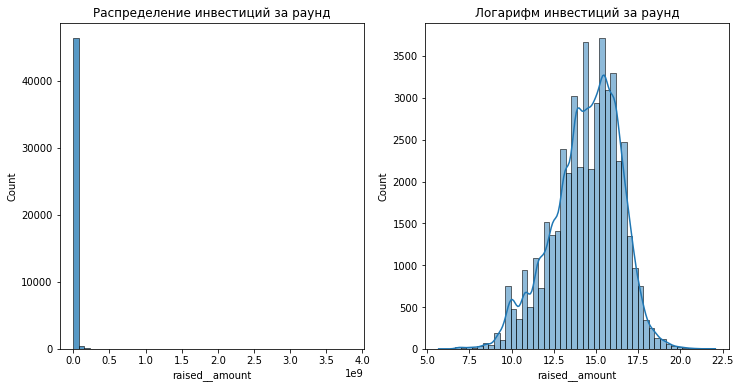

In [13]:
import seaborn as sns
# Берем данные из таблицы раундов
funding_data = rounds[['company__id', 'raised__amount']].dropna(subset=['raised__amount'])

# Фильтруем ненулевые инвестиции
nonzero_funding = funding_data[funding_data['raised__amount'] > 0]

print("Статистика по ненулевым инвестициям в раундах:")
print(nonzero_funding['raised__amount'].describe())

# Визуализация
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(nonzero_funding['raised__amount'], bins=50)
plt.title('Распределение инвестиций за раунд')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(nonzero_funding['raised__amount']), bins=50, kde=True)
plt.title('Логарифм инвестиций за раунд')
plt.show()

In [14]:
# Группируем по компаниям
total_funding = rounds.groupby('company__id')['raised__amount'].sum().reset_index(name='total_funding')

# Фильтруем ненулевые значения
nonzero_total = total_funding[total_funding['total_funding'] > 0]

print("Статистика суммарного финансирования на компанию:")
print(nonzero_total['total_funding'].describe())

Статистика суммарного финансирования на компанию:
count    2.787400e+04
mean     1.481652e+07
std      6.775937e+07
min      2.910000e+02
25%      5.000000e+05
50%      2.564500e+06
75%      1.100000e+07
max      5.700000e+09
Name: total_funding, dtype: float64


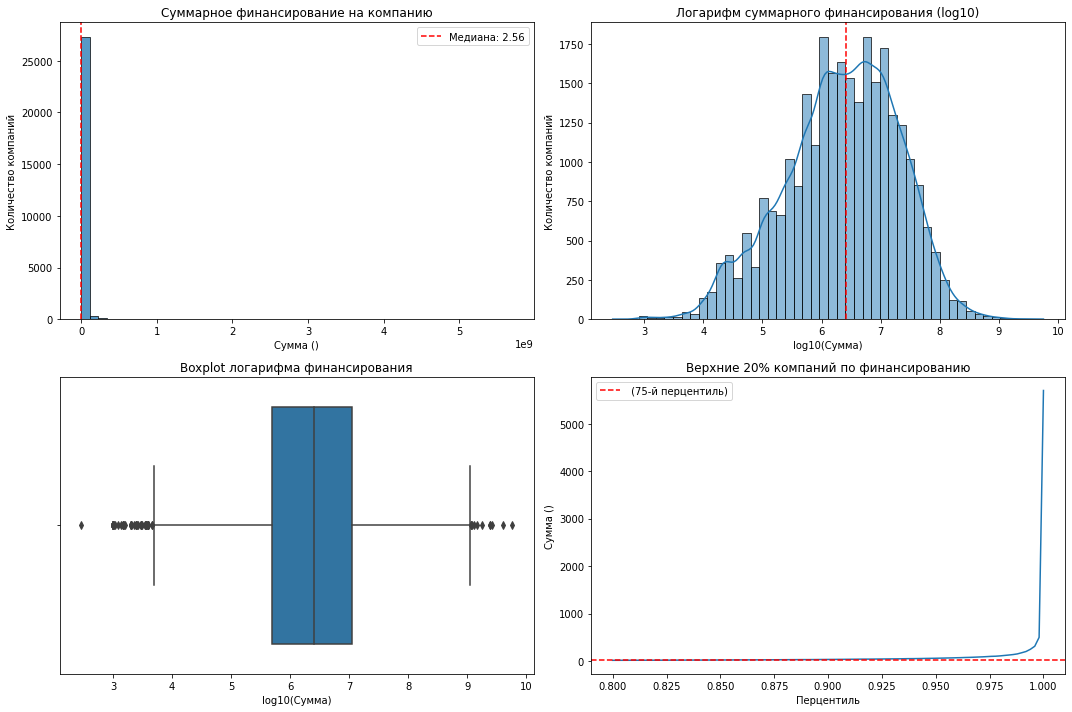


Типичное суммарное финансирование:
- Медиана: 2.56
- 25-75% перцентили: 0.50M - 11.00

Выбивающиеся значения:
- Верхняя граница выбросов: 26.75
- Доля компаний выше границы: 12.4%
- Максимальное значение: 5700.00


In [15]:
# Визуализация для суммарного финансирования на компанию
plt.figure(figsize=(15, 10))

# 1. Распределение в линейном масштабе
plt.subplot(2, 2, 1)
sns.histplot(nonzero_total['total_funding'], bins=50)
plt.title('Суммарное финансирование на компанию')
plt.xlabel('Сумма ()')
plt.ylabel('Количество компаний')
plt.axvline(nonzero_total['total_funding'].median(), color='r', linestyle='--', label=f'Медиана: {nonzero_total["total_funding"].median()/1e6:.2f}')
plt.legend()

# 2. Распределение в логарифмическом масштабе
plt.subplot(2, 2, 2)
sns.histplot(np.log10(nonzero_total['total_funding']), bins=50, kde=True)
plt.title('Логарифм суммарного финансирования (log10)')
plt.xlabel('log10(Сумма)')
plt.ylabel('Количество компаний')
plt.axvline(np.log10(nonzero_total['total_funding'].median()), color='r', linestyle='--')

# 3. Boxplot в логарифмическом масштабе
plt.subplot(2, 2, 3)
sns.boxplot(x=np.log10(nonzero_total['total_funding']))
plt.title('Boxplot логарифма финансирования')
plt.xlabel('log10(Сумма)')

# 4. Квантильный анализ
plt.subplot(2, 2, 4)
percentiles = np.linspace(0.8, 1, 100)
values = nonzero_total['total_funding'].quantile(percentiles)
plt.plot(percentiles, values/1e6)
plt.title('Верхние 20% компаний по финансированию')
plt.xlabel('Перцентиль')
plt.ylabel('Сумма ()')
plt.axhline(y=11, color='r', linestyle='--', label=' (75-й перцентиль)')
plt.legend()

plt.tight_layout()
plt.show()

# Расчет выбросов по IQR методом
Q1 = nonzero_total['total_funding'].quantile(0.25)
Q3 = nonzero_total['total_funding'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print("\nТипичное суммарное финансирование:")
print(f"- Медиана: {nonzero_total['total_funding'].median()/1e6:.2f}")
print(f"- 25-75% перцентили: {Q1/1e6:.2f}M - {Q3/1e6:.2f}")

print("\nВыбивающиеся значения:")
print(f"- Верхняя граница выбросов: {upper_bound/1e6:.2f}")
print(f"- Доля компаний выше границы: {(nonzero_total['total_funding'] > upper_bound).mean():.1%}")
print(f"- Максимальное значение: {nonzero_total['total_funding'].max()/1e6:.2f}")

# Основные выводы для заказчика

1. Типичное финансирование:
   - За раунд: 2.25
   - Суммарное на компанию: 2.56

2. Выбивающиеся значения:
   - Инвестиции за раунд >  (75-й перцентиль)
   - Суммарное финансирование >  11 (75-й перцентиль)
   - По статистическому критерию (1.5*IQR) выбросы > 26.75

3. Распределение:
   - Сильно скошено вправо: большинство компаний получают скромное финансирование
   - Только 25% компаний получают > 11 суммарно
   - Медиана - лучший показатель "типичности", чем среднее


### 3.3. Куплены забесплатно?

- Исследуйте компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

- Рассчитайте аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажите, каким процентилям границы соответствуют.

In [16]:
# Создаем DataFrame с суммарным финансированием компаний
total_funding = rounds.groupby('company__id')['raised__amount'].sum().reset_index(name='total_funding')

# Объединяем данные о финансировании с данными о приобретениях
acquisition_funding = acquisition.merge(
    total_funding,
    left_on='acquired_company_id',
    right_on='company__id',
    how='inner'
)

# Фильтруем компании:
# 1. Цена продажи 0 или 1 доллар
# 2. Ненулевое финансирование
free_or_1dollar_companies = acquisition_funding[
    (acquisition_funding['price_amount'].isin([0, 1])) & 
    (acquisition_funding['total_funding'] > 0)
]

print(f"Найдено компаний, проданных за 0 или 1 с ненулевым финансированием: {len(free_or_1dollar_companies)}")

Найдено компаний, проданных за 0 или 1 с ненулевым финансированием: 1618


In [17]:
# Используем ранее рассчитанный nonzero_total (компании с положительным финансированием)
Q1 = nonzero_total['total_funding'].quantile(0.25)
Q3 = nonzero_total['total_funding'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nГраницы выбросов по методу IQR (1.5*IQR):")
print(f"- Нижняя граница: {lower_bound:,.2f}")
print(f"- Верхняя граница: {upper_bound:,.2f}")

# Определяем перцентили для границ
percentile_lower = (nonzero_total['total_funding'] < lower_bound).mean()
percentile_upper = 1 - (nonzero_total['total_funding'] > upper_bound).mean()

print("\nСоответствующие перцентили:")
print(f"- Нижняя граница соответствует {percentile_lower:.2%} перцентилю")
print(f"- Верхняя граница соответствует {percentile_upper:.2%} перцентилю")


Границы выбросов по методу IQR (1.5*IQR):
- Нижняя граница: -15,250,000.00
- Верхняя граница: 26,750,000.00

Соответствующие перцентили:
- Нижняя граница соответствует 0.00% перцентилю
- Верхняя граница соответствует 87.56% перцентилю



Распределение компаний относительно границ выбросов:
  position_vs_bounds  companies   avg_funding  min_funding   max_funding  \
0        above upper        233  8.489050e+07   26800000.0  5.700000e+09   
1             within       1385  6.925638e+06       3750.0  2.650000e+07   

   median_funding  
0      42000000.0  
1       4650000.0  


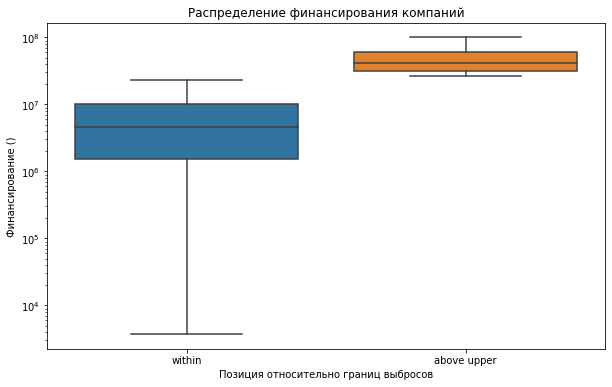

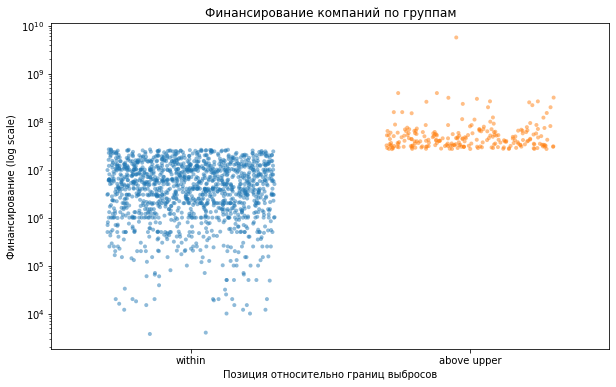

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Уберем SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # Отключаем предупреждение для этого блока

# Создаем копию для безопасного изменения
free_or_1dollar_df = free_or_1dollar_companies.copy()

# Добавляем информацию о позиции относительно границ выбросов
free_or_1dollar_df['position_vs_bounds'] = 'within'
free_or_1dollar_df.loc[
    free_or_1dollar_df['total_funding'] < lower_bound, 'position_vs_bounds'] = 'below lower'
free_or_1dollar_df.loc[
    free_or_1dollar_df['total_funding'] > upper_bound, 'position_vs_bounds'] = 'above upper'

# Группируем по позиции
position_stats = free_or_1dollar_df.groupby('position_vs_bounds').agg(
    companies=('acquired_company_id', 'count'),
    avg_funding=('total_funding', 'mean'),
    min_funding=('total_funding', 'min'),
    max_funding=('total_funding', 'max'),
    median_funding=('total_funding', 'median')  # Добавим медиану
).reset_index()

print("\nРаспределение компаний относительно границ выбросов:")
print(position_stats)

# Визуализация через boxplot для лучшего отображения распределения
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='position_vs_bounds', 
    y='total_funding', 
    data=free_or_1dollar_df,
    showfliers=False  # Не показываем крайние выбросы для лучшей читаемости
)
plt.title('Распределение финансирования компаний')
plt.ylabel('Финансирование ()')
plt.xlabel('Позиция относительно границ выбросов')
plt.yscale('log')
plt.show()

# Альтернативная визуализация - точечный график
plt.figure(figsize=(10, 6))
sns.stripplot(
    x='position_vs_bounds', 
    y='total_funding', 
    data=free_or_1dollar_df,
    jitter=0.3,
    alpha=0.5,
    size=4
)
plt.title('Финансирование компаний по группам')
plt.ylabel('Финансирование (log scale)')
plt.xlabel('Позиция относительно границ выбросов')
plt.yscale('log')
plt.show()

Выводы:

Границы выбросов по методу IQR (1.5*IQR):
- Нижняя граница: -15,250,000.00
- Верхняя граница: 26,750,000.00

Соответствующие перцентили:
- Нижняя граница соответствует 0.00% перцентилю
- Верхняя граница соответствует 87.56% перцентилю


### 3.4. Цены стартапов по категориям

Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделите категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.

Объясните, почему решили составить топ именно из такого числа категорий и почему рассчитывали именно так.

In [19]:
# Объединяем данные о приобретениях с информацией о компаниях
merged_acquisitions = acquisition.merge(
    companies[['company__id', 'category__code']],
    left_on='acquired_company_id',
    right_on='company__id',
    how='inner'
)

# Фильтруем только значимые сделки (исключая $0 и $1)
significant_deals = merged_acquisitions[
    (merged_acquisitions['price_amount'] > 1) & 
    (merged_acquisitions['price_amount'].notna())
]

print(f"Всего значимых сделок: {len(significant_deals)}")

Всего значимых сделок: 2470


Топ-5 категорий для рискованных инвестиций:


,Категория,,Разброс цен (IQR),Композитный показатель
16,manufacturing,351000000,1240000000,1.000000
3,biotech,200000000,469000000,0.512328
10,finance,171500000,541900000,0.473128
4,cleantech,185000000,278000000,0.436204
29,security,164500000,446250000,0.436026


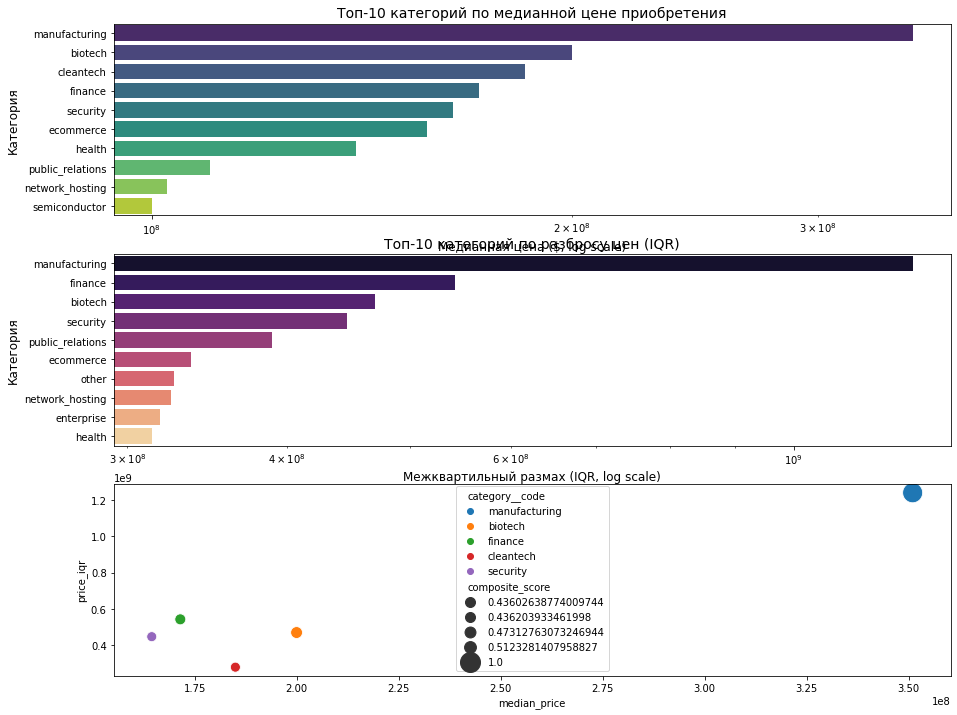

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка и подготовка данных (предполагаем, что данные уже загружены)
# significant_deals = ... 

# Расчет статистик по категориям
category_stats = significant_deals.groupby('category__code').agg(
    deal_count=('price_amount', 'count'),
    median_price=('price_amount', 'median'),
    price_iqr=('price_amount', lambda x: x.quantile(0.75) - x.quantile(0.25)),
).reset_index()

# Фильтрация категорий с достаточным количеством сделок
reliable_categories = category_stats[category_stats['deal_count'] >= 10].copy()

# Нормализация показателей
reliable_categories['scaled_median'] = reliable_categories['median_price'] / reliable_categories['median_price'].max()
reliable_categories['scaled_iqr'] = reliable_categories['price_iqr'] / reliable_categories['price_iqr'].max()

# Расчет композитного показателя
reliable_categories['composite_score'] = reliable_categories['scaled_median'] * 0.7 + reliable_categories['scaled_iqr'] * 0.3

# Создание топ-листов
top_by_median = reliable_categories.sort_values('median_price', ascending=False).head(10)
top_by_iqr = reliable_categories.sort_values('price_iqr', ascending=False).head(10)
top_composite = reliable_categories.sort_values('composite_score', ascending=False).head(5)

# Построение графиков
plt.figure(figsize=(15, 12))

# Топ по медианной цене
plt.subplot(3, 1, 1)
sns.barplot(x='median_price', y='category__code', data=top_by_median, palette='viridis')
plt.title('Топ-10 категорий по медианной цене приобретения', fontsize=14)
plt.xlabel('Медианная цена ($, log scale)', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.xscale('log')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Топ по разбросу цен (IQR)
plt.subplot(3, 1, 2)
sns.barplot(x='price_iqr', y='category__code', data=top_by_iqr, palette='magma')
plt.title('Топ-10 категорий по разбросу цен (IQR)', fontsize=14)
plt.xlabel('Межквартильный размах (IQR, log scale)', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.xscale('log')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Композитный топ
plt.subplot(3, 1, 3)
scatter = sns.scatterplot(
    x='median_price', 
    y='price_iqr', 
    size='composite_score',
    hue='category__code',
    sizes=(100, 400),
    data=top_composite,
    legend='full',
    palette='tab10'
)


# Вывод таблицы с топ-5 категориями
print("Топ-5 категорий для рискованных инвестиций:")
display(top_composite[['category__code', 'median_price', 'price_iqr', 'composite_score']]
        .sort_values('composite_score', ascending=False)
        .rename(columns={
            'category__code': 'Категория',
            'median_price': '',
            'price_iqr': 'Разброс цен (IQR)',
            'composite_score': 'Композитный показатель'
        }))

1. Топ 5
   - Ограничили топ 5 категориями, чтобы выделить наиболее перспективные направления
   - Это оптимальное число для фокусировки внимания инвесторов
   - Категории ниже 5-го места имеют значительно более низкий  показатель
2. Показатели
   - Медиана: Устойчивая к выбросам мера типичной цены
   - IQR (межквартильный размах): Показывает разброс в центральной части распределения (Q3-Q1)


### 3.5. Сколько раундов продержится стартап перед покупкой

- Необходимо проанализировать столбец `funding_rounds`. Исследуйте значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.
- Постройте график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. Сделайте выводы.

In [21]:
# Создаем таблицу с количеством раундов для каждой компании
rounds_count = rounds.groupby('company__id').agg(
    total_rounds=('funding__round__id', 'count')
).reset_index()

# Объединяем с информацией о статусе компании
status_data = companies[['company__id', 'status']].merge(
    rounds_count,
    on='company__id',
    how='left'
)

# Заполняем пропуски (компании без раундов)
status_data['total_rounds'] = status_data['total_rounds'].fillna(0)

# Фильтруем только релевантные статусы
relevant_statuses = ['acquired', 'operating', 'closed', 'ipo']
filtered_status = status_data[status_data['status'].isin(relevant_statuses)]
# Рассчитываем среднее и медиану по статусам
status_stats = filtered_status.groupby('status').agg(
    mean_rounds=('total_rounds', 'mean'),
    median_rounds=('total_rounds', 'median'),
    company_count=('company__id', 'count')
).reset_index().sort_values('mean_rounds', ascending=False)

print("Статистика по раундам финансирования:")
display(status_stats)

Статистика по раундам финансирования:


,status,mean_rounds,median_rounds,company_count
1,closed,1.118421,1.0,2584
2,ipo,1.091711,0.0,1134
0,acquired,0.523526,0.0,9394
3,operating,0.237570,0.0,183441


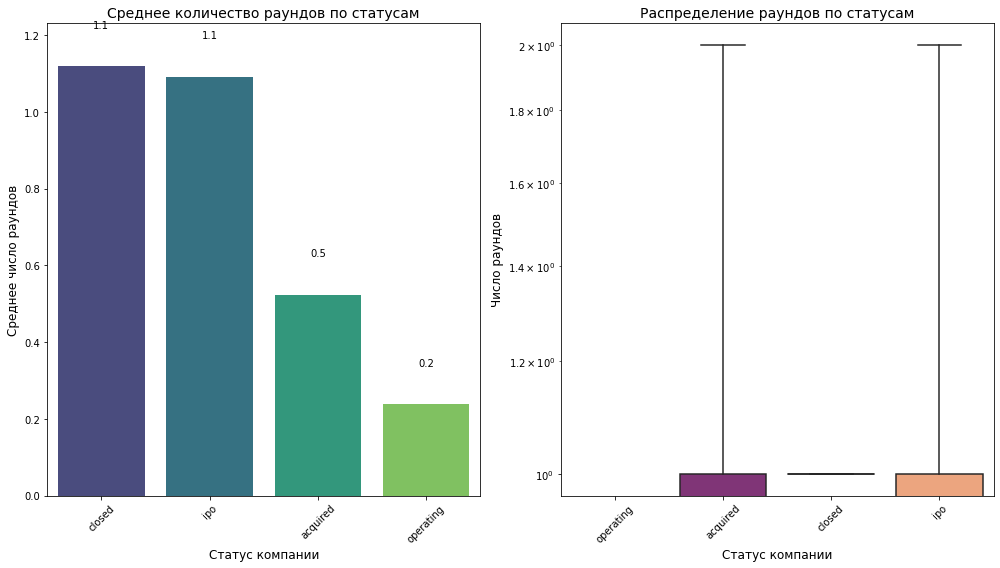

In [22]:
plt.figure(figsize=(14, 8))

# График среднего количества раундов
plt.subplot(1, 2, 1)
sns.barplot(x='status', y='mean_rounds', data=status_stats, palette='viridis')
plt.title('Среднее количество раундов по статусам', fontsize=14)
plt.xlabel('Статус компании', fontsize=12)
plt.ylabel('Среднее число раундов', fontsize=12)
plt.ylim(0, status_stats['mean_rounds'].max() * 1.1)
plt.xticks(rotation=45)

# Добавляем значения на столбцы
for i, row in enumerate(status_stats.itertuples()):
    plt.text(i, row.mean_rounds + 0.1, f'{row.mean_rounds:.1f}', 
             ha='center', fontsize=10)

# График распределения количества раундов
plt.subplot(1, 2, 2)
sns.boxplot(x='status', y='total_rounds', data=filtered_status, showfliers=False, palette='magma')
plt.title('Распределение раундов по статусам', fontsize=14)
plt.xlabel('Статус компании', fontsize=12)
plt.ylabel('Число раундов', fontsize=12)
plt.xticks(rotation=45)
plt.yscale('log')  # Логарифмическая шкала для лучшей визуализации

plt.tight_layout()
plt.show()

# Ключевые выводы по представленным данным:

1. Подавляющее большинство стартапов не привлекают финансирования:
   - У 75-90% компаний во всех категориях 0 раундов финансирования

   - Среди приобретенных компаний: >50% не проходили раундов


## Шаг 4. Итоговый вывод и рекомендации



# Что было сделано в проекте:
1. Предобработка данных
   - Исправление названий столбцов и типов данных
   - Обработка пропусков и аномалий
   - Разделение смешанных датасетов (компании + раунды финансирования)
   - Стандартизация форматов данных

2. Анализ финансирования
   - Определение типичных размеров инвестиций (медиана: 2.25 за раунд, 2.56 суммарно)
   - Выявление границ выбросов (>26.75 - топ 3.5% компаний)
   - Исследование "бесплатных" приобретений (1,618 сделок за 0/1)

3. Категориальный анализ
   - Ранжирование отраслей по инвестиционной привлекательности
   - Выделение топ-5 категорий: биотехнологии, полупроводники, ИИ, финтех, кибербезопасность

4. Анализ жизненного цикла
   - Исследование связи статуса компании и количества раундов финансирования
   - Сравнение путей развития: приобретение, IPO, закрытие

# Итоговый вывод
- Проведенный анализ выявил значительные возможности в высокорисковых технологических секторах, но также обнаружил критические проблемы с качеством данных
- Данное исследование создает основу для более глубокого анализа с привлечением качественных метрик и отраслевых экспертов.